In [2]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL

import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

from collections import defaultdict

import matplotlib as mpl
import matplotlib.pyplot as plt
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (12, 12),

    "axes.titlesize": 28,
    "axes.labelsize": 24,
    "legend.fontsize": 20,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,

    "axes.linewidth": 2,
    "axes.edgecolor": "black",

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,
    "ytick.minor.width": 2,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
}
mpl.rcParams.update(config)

import astropy.units as u
import astropy

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(("./DJAV4.2Catalog.pkl"))

print("="*50)
print(f"Total {(DJAv4Catalog.sample_num())} sample objectss loaded.")
print("="*50)

Total 1102 sample objectss loaded.


Selected 1102 targets for analysis.
Categorizing 1102 objects...
Group 0: N=102, Mean BD=0.000 +/- 0.002
Group 1: N=148, Mean BD=0.062 +/- 0.002
Group 2: N=150, Mean BD=0.147 +/- 0.002
Group 3: N=111, Mean BD=0.246 +/- 0.003
Group 4: N=69, Mean BD=0.363 +/- 0.005
Group 5: N=44, Mean BD=0.517 +/- 0.006
Group 6: N=34, Mean BD=0.731 +/- 0.016

Computing average spectra...
Applied masks to 9 regions.
  Group 0: Processed.
Applied masks to 9 regions.
  Group 1: Processed.
Applied masks to 9 regions.
  Group 2: Processed.
Applied masks to 9 regions.
  Group 3: Processed.
Applied masks to 9 regions.
  Group 4: Processed.
Applied masks to 9 regions.
  Group 5: Processed.
Applied masks to 9 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve with FULL error propagation (Flux + Tau).
Error propagation successful. Ready for MCMC.
Running MCMC with 32 walkers for 3000 steps (Monotonicity Constrained)...


100%|██████████| 3000/3000 [00:05<00:00, 565.95it/s]


MCMC Best Fit Coeffs: [ 0.00853828 -0.19425636  1.51292084 -2.15844239]


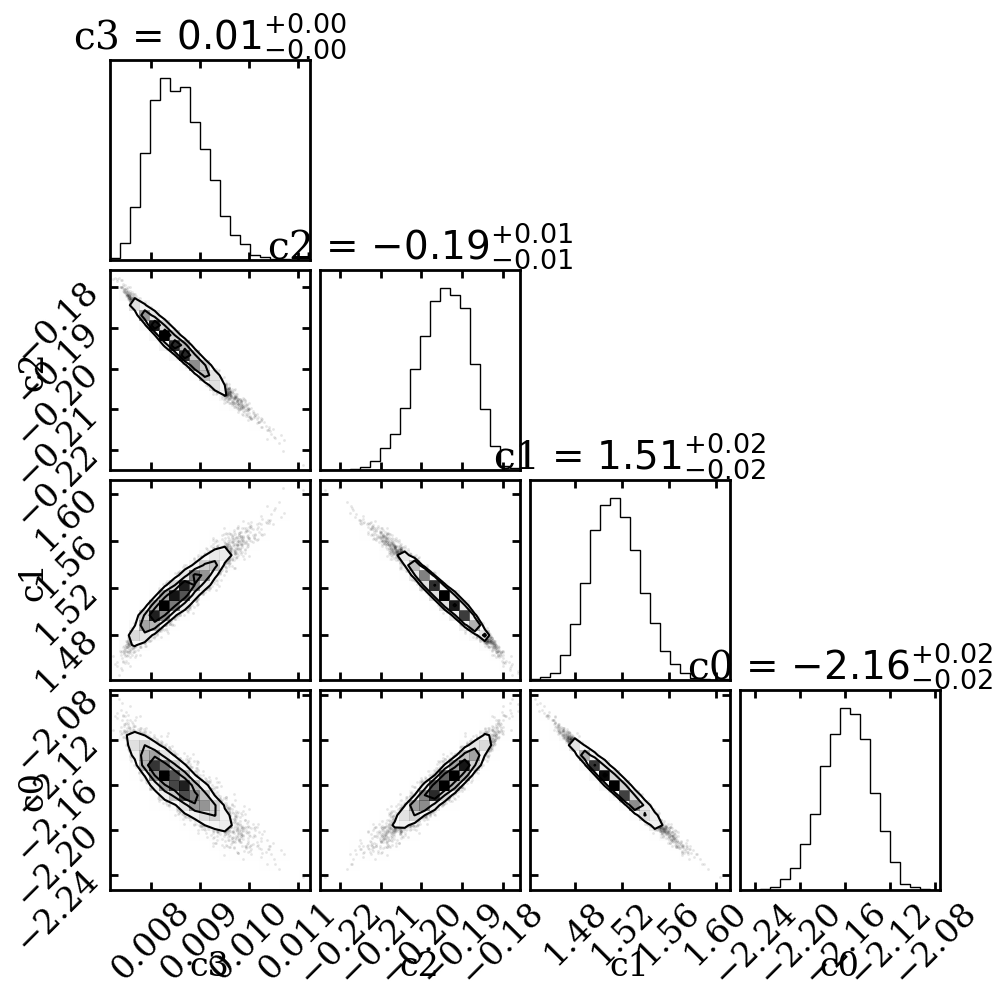

Derived Parameters: S=2.6639, Intercept=0, Rv=5.754


In [3]:
# %%
# 1. 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import corner  # 用于画 MCMC 的角图 (Corner Plot)

# 假设你的 Catalog 已经加载好了
# from FunctionLib import DJAv4Catalog ...

# 实例化分析器
analyst = FL.DustAttenuationAnalyst(DJAv4Catalog, wavelength_grid=(1250, 8000))

# %%
# 2. 准备数据 ID 列表
# 这一步根据你的筛选逻辑来，比如只选 Sample_Flag 为 True 的
target_ids = []
for survey_id, entry in DJAv4Catalog.catalog_iterator():
    # 这里可以加你的筛选条件
    if entry.get('sample_flag') is True:
        target_ids.append(survey_id)

print(f"Selected {len(target_ids)} targets for analysis.")

# %%
# 3. 运行基础管线 (Data Pipeline)
# 加载并分组
analyst.load_and_group_objects(target_ids)

# 计算平均光谱 (这一步会自动计算 average_flux_err)
analyst.compute_average_spectra()

# 计算平滑参考谱 (Group 0)
analyst.compute_smooth_reference(window_len=101, poly_order=3)

# %%
# 4. 计算 Q 曲线并进行误差传播 (关键步骤)
# mode='smoothed': 使用平滑后的参考谱，减少参考谱带来的噪声
# 这一步会自动利用之前的 flux_err 计算出 effective_curve_err
analyst.compute_attenuation_curves(mode='smoothed')

# 检查一下误差是否计算成功
if analyst.effective_curve_err is not None:
    print("Error propagation successful. Ready for MCMC.")
else:
    print("Warning: Error array is empty.")

# %%
# 5. 运行 MCMC 拟合 (Bayesian Inference)
# nwalkers: 游走者数量 (建议 32 或 64)
# nsteps: 步数 (建议 2000-5000，取决于收敛速度)
# poly_order: 拟合阶数 (通常 3 阶多项式对 1/lambda 足够)
analyst.run_mcmc_fitting(nwalkers=32, nsteps=3000, poly_order=3)

# 绘制 MCMC 拟合结果 (带 95% 误差带的蝴蝶结图)

# analyst.plot_mcmc_results(plot_samples=True, n_samples=300)

# # %%
# (可选) 绘制 Corner Plot 查看参数相关性
# 这有助于查看 c1, c2, c3 系数之间是否存在简并
if hasattr(analyst, 'mcmc_samples'):
    flat_samples = analyst.mcmc_samples
    labels = ["c3", "c2", "c1", "c0"] # 对应三次多项式系数
    fig = corner.corner(
        flat_samples,
        labels=labels,
        show_titles=True,
        title_fmt=".2f"
    )
    plt.show()

# %%
# 6. 推导物理参数 (Rv 和 Scaling Factor)
# 这一步会自动使用 MCMC 得到的最佳拟合系数 (中位数)
# 我们可以设定无穷远处的截距 (Calzetti Extrapolation ~ -0.89)
analyst.derive_k_curve_parameters(intercept_val=0)

# %%
# 7. 绘制最终的对比图 (Publication Quality)

# 7.1 绘制 k(lambda) 曲线 (Normalized Extinction Curve)
# analyst.plot_derived_k_curve()

# analyst.plot_extinction_curves_comparison()

# 画红化曲线对比图，带100条猜测线
# analyst.plot_reddening_curve_comparison(
#     if_show=True,
#     curve_label="This Work",
#     curve_color="dodgerblue",
#     plot_mcmc_samples=True,  # 开启绘制样本线
#     n_samples=300            # 画100条
# )
# 保存图片
# fig.savefig("Final_Reddening_Curve.pdf", bbox_inches='tight')

In [4]:
def plot_fit_vs_calzetti(self,if_show=True, if_plot_samples=False,n_samples=None):
    """绘制图表 1：Effective Q_lambda 数据 vs 多项式拟合 vs Calzetti"""
    if self.poly_coeffs is None: self.fit_polynomial()

    wave = self.effective_curve_wave
    x = 10000.0 / wave
    y_fit = self._poly_shape(x)

    fig, ax = plt.subplots()

    # 原始数据
    # ax.plot(wave, self.effective_curve, color='blue', lw=3, alpha=0.4,
    #         label=f'Calculated Curve ({self.curve_mode} ref)',zorder=1)
    ax.plot(wave, self.effective_curve, color="#024CB3", lw=1.5, alpha=0.4,
            label='Stacked Data',zorder=1)
    ax.errorbar(wave, self.effective_curve, yerr=self.effective_curve_err,
                fmt='o', color="#3488FC", alpha=0.2, markersize=2, capsize=2,zorder=1)

    # 拟合曲线
    ax.plot(wave, y_fit, color="#002147", lw=4, ls='--',
            label='This Study',zorder=5)
    # Calzetti 参考
    calz = self.get_calzetti_law(wave)
    ax.plot(wave, calz, color='red', lw=4, label='Calzetti et al., (2000)',zorder=4)

    if if_plot_samples:
        n_total=len(self.mcmc_samples)
        if n_samples is None or n_samples > n_total:
            n_samples=n_total
        selected_indices = np.random.choice(n_total, size=n_samples, replace=False)
        label_added=False
        label_text='MCMC Fit Samples'
        for idx in selected_indices:
            sample_coeffs = self.mcmc_samples[idx]
            sample_shape = np.polyval(sample_coeffs, x)
            ax.plot(wave, sample_shape, color='gray', lw=1, alpha=0.1,zorder=2)
            label_added=True



    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel(r'$Q_\lambda$ (Attenuation Curve)')
    # ax.set_title(r'Effective Attenuation Curve: Fit vs Calzetti')
    ax.set_xlim(1500, 8000)
    ax.set_ylim(-1, 3)
    ax.legend()
    ax.grid(True, alpha=0.2)
    if if_show:
        plt.show()
    else:
        return fig, ax


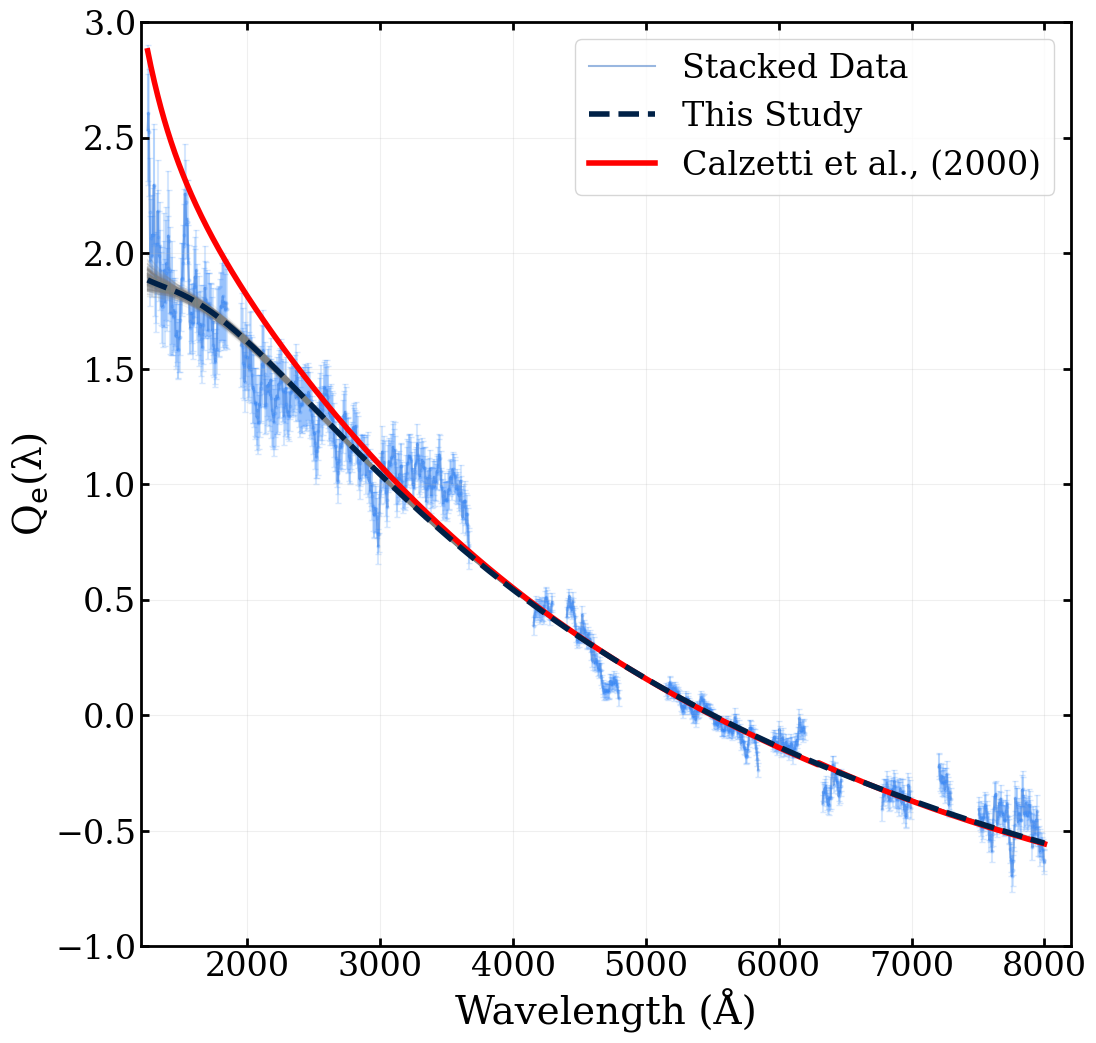

In [7]:
fig, ax =plot_fit_vs_calzetti(analyst,if_show=False,if_plot_samples=True,n_samples=300)

# ax.set_title("Effective Attenuation Curve Normalized at 5500 Å",fontsize=32)
ax.set_xlabel("Wavelength (Å)",fontsize=28)
ax.set_ylabel(r"Q$_\text{e}$(λ)",fontsize=28)
ax.set_xlim(1200,8200)
ax.legend(fontsize=24)
plt.savefig("Global_Effective_Attenuation_Curve_Normalized_at_5500A.pdf", bbox_inches='tight')

In [9]:

def plot_reddening_curve_comparison(self,
                                        if_show=True,
                                        if_input=False,
                                        fig=None,
                                        ax=None,
                                        curve_label='Derived Curve (Data)',
                                        curve_color='blue',
                                        draw_background=True,
                                        plot_mcmc_samples=False,  # <--- 新接口
                                        n_samples=100):           # <--- 新接口
        """
        绘制去 Rv 化的红化对比图，支持叠加 MCMC 样本线。
        """
        if self.scaling_factor is None: self.derive_k_curve_parameters()

        if if_input:
            if fig is None or ax is None:
                raise ValueError("If if_input is True, fig and ax must be provided.")
        else:
            fig, ax = plt.subplots()
            draw_background = True

        x_grid = np.linspace(0.5, 8.2, 1000) # 1/um

        # ==========================================
        # 1. 准备 MCMC 样本线 (如果在 MCMC 之后)
        # ==========================================
        sample_lines_y = []
        if plot_mcmc_samples and hasattr(self, 'mcmc_samples'):
            # 定义 B 和 V 的频率
            x_B, x_V = 1.0/0.44, 1.0/0.55

            # 随机抽取样本
            n_total = len(self.mcmc_samples)
            inds = np.random.randint(n_total, size=n_samples)

            for ind in inds:
                coeffs = self.mcmc_samples[ind]
                # 提取形状部分 (假设只用高阶项决定形状，如果拟合包含c0但假设c0不影响形状)
                # 注意：这里的逻辑必须与 _poly_shape_cubic_only 保持一致
                # theta = [c3, c2, c1, c0]
                c3, c2, c1 = coeffs[0], coeffs[1], coeffs[2]

                # 局部函数计算该样本的形状值
                def shape_func(x):
                    return c3 * x**3 + c2 * x**2 + c1 * x

                val_grid = shape_func(x_grid)
                val_B = shape_func(x_B)
                val_V = shape_func(x_V)

                # 计算归一化曲线
                y_sample = (val_grid - val_V) / (val_B - val_V)
                sample_lines_y.append(y_sample)

        # ==========================================
        # 2. 计算最佳拟合曲线 (Best Fit)
        # ==========================================
        shape_grid = self._poly_shape_cubic_only(x_grid)
        shape_V = self._poly_shape_cubic_only(1.0/0.55)
        shape_B = self._poly_shape_cubic_only(1.0/0.44)
        y_derived = (shape_grid - shape_V) / (shape_B - shape_V)

        # ==========================================
        # 3. 绘制背景参考线
        # ==========================================
        if draw_background:
            y_calz = self._get_normalized_reddening(x_grid, 'calzetti')
            y_mw = self._get_normalized_reddening(x_grid, 'mw')
            y_smc = self._get_normalized_reddening(x_grid, 'smc')

            ax.plot(x_grid, y_mw, color='blue', ls=':', lw=4, label='Milky Way (CCM89)')
            ax.plot(x_grid, y_smc, color='green', ls='-.', lw=4, label='SMC (Pei92)')
            ax.plot(x_grid, y_calz, color='red', ls='--', lw=4, label='Calzetti (2000)')

            # 辅助线
            x_V, x_B = 1.0/0.55, 1.0/0.44
            ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
            ax.axvline(x_V, color='gray', linestyle='-', alpha=0.3)
            ax.scatter([x_V], [0], color='black', s=80, zorder=10)
            ax.text(x_V, 0.5, 'V (5500$\AA$)\nNormalized to 0', rotation=90, color='gray', fontsize=20, ha='right')

            ax.axhline(1, color='gray', linestyle=':', alpha=0.3)
            ax.axvline(x_B, color='gray', linestyle=':', alpha=0.3)
            ax.scatter([x_B], [1], color='black', s=80, zorder=10)
            ax.text(x_B, 1.5, 'B (4400$\AA$)\nNormalized to 1', rotation=90, color='gray', fontsize=20, ha='right')

            ax.set_xlabel(r'Inverse Wavelength λ$^\text{-1}$ ($\mu m^{-1}$)')
            ax.set_ylabel('E(λ - V) / E(B - V)')
            # ax.set_title(r'Reddening Curves Comparison (Independent of $R_V$)')
            ax.set_xlim(0.5, 8)
            ax.set_ylim(-2, 12)
            ax.set_yticks(np.arange(-2.0, 13.0, 2.0).round(1))

            # 顶部波长轴
            ax2 = ax.twiny()
            ticks = [10000, 5500, 4400, 3000, 2000, 1500]
            ax2.set_xlim(ax.get_xlim())
            ax2.set_xticks([10000.0/t for t in ticks])
            ax2.set_xticklabels([str(t) for t in ticks],fontsize=18)

            ax2.set_xlabel(r'Wavelength (Å)', fontsize=28)
            ax.grid(True, alpha=0.2)

        # ==========================================
        # 4. 绘制 MCMC 样本线 (在最佳拟合线下面绘制)
        # ==========================================
        if sample_lines_y:
            # 将样本线绘制在较低的图层 (zorder=1)
            for y_samp in sample_lines_y:
                ax.plot(x_grid, y_samp,
                        color='gray',
                        alpha=0.1,       # 保持极低透明度
                        lw=2,             # 保持细线
                        zorder=1)         # 放在底层

        # ==========================================
        # 5. 绘制最佳拟合线 (前景强调)
        # ==========================================

        # 技巧：先画一条粗的白色线作为背景 (Halo)，把主线“托”出来
        # 这样即使背景很乱，主线周围也会有一圈白色光晕，使其清晰可见
        # ax.plot(x_grid, y_derived,
        #         color='white',
        #         lw=4,             # 比主线粗，作为描边
        #         alpha=0.8,        # 稍微带一点透明度，让网格线隐约可见，或者设为1.0完全遮挡
        #         zorder=4)         # 在样本线之上，主线之下

        # 再画真正的最佳拟合线
        ax.plot(x_grid, y_derived,
                color="#002147",
                lw=4,             # 增加线宽 (比如从 2 改为 3 或 4)
                label=curve_label,
                zorder=5)         # 放在最顶层
        # 图例去重
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper left')

        plt.tight_layout()
        if if_show:
            plt.show()
        return fig, ax


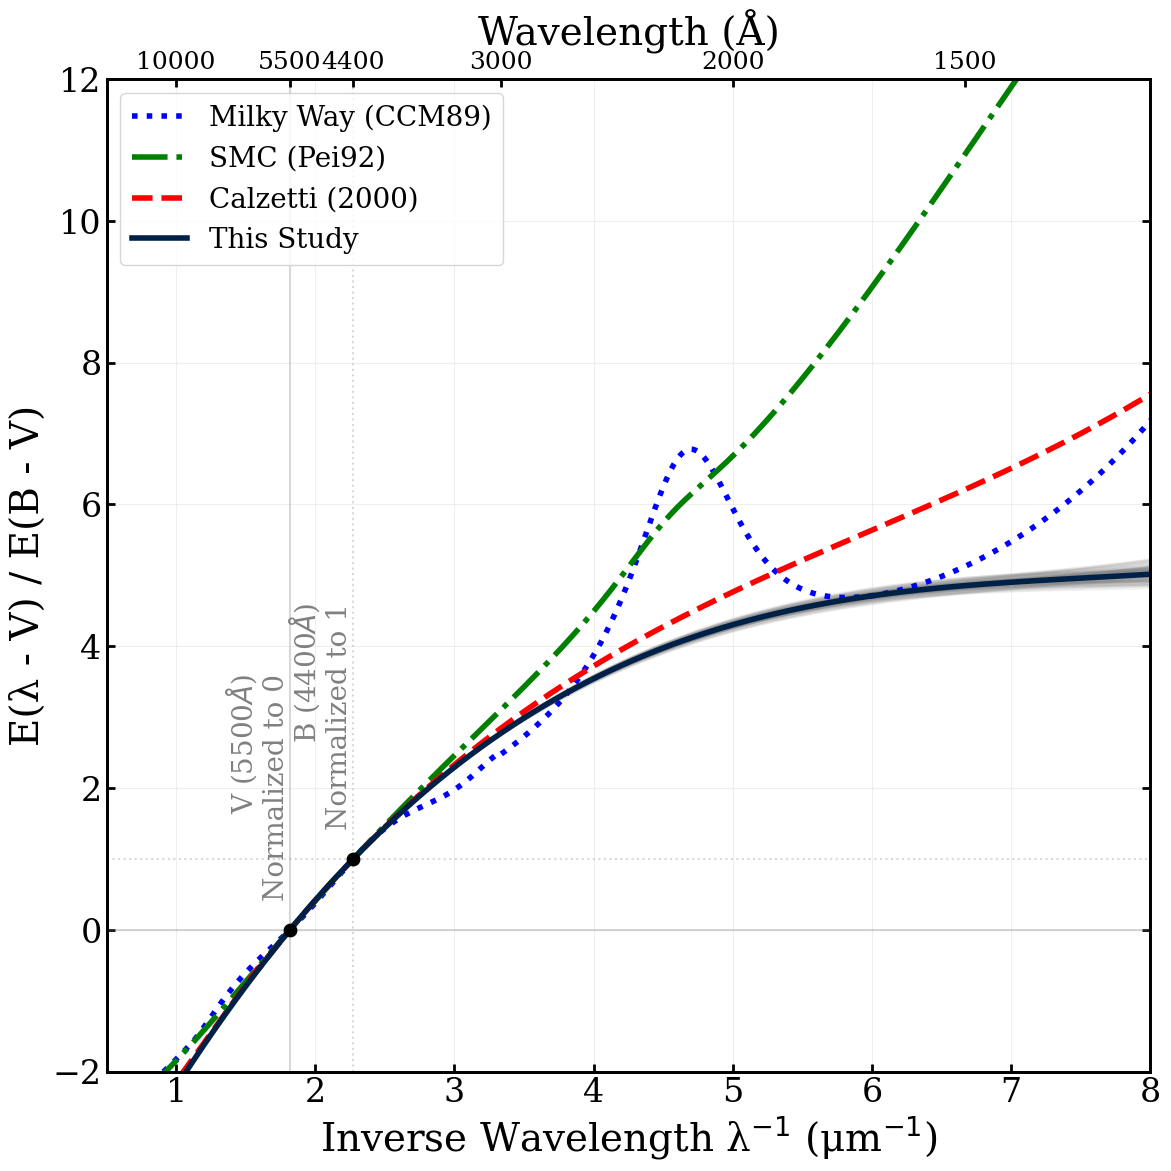

In [10]:
fig, ax=plot_reddening_curve_comparison(self=analyst,
    if_show=False,
    curve_label="This Study",
    curve_color="dodgerblue",
    plot_mcmc_samples=True,  # 开启绘制样本线
    n_samples=100            # 画100条
)
ax.set_xlabel('Inverse Wavelength λ$^{-1}$ (μm$^{-1}$)',fontsize=28)
ax.set_ylabel("E(λ - V) / E(B - V)",fontsize=28)
# ax.set_ylim(-2,9)

fig.savefig("Global_Reddening_Curve_Comparison.pdf", bbox_inches='tight')